# MarkDiffusion PyPI Package Test

This notebook tests the `markdiffusion` package (v0.1.1) with:
- **TR (Tree-Ring)**: Image watermarking algorithm
- **VideoMark**: Video watermarking algorithm

In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

## 1. Image Watermarking with Tree-Ring (TR)

In [1]:
!pip install markdiffusion
# or to install by conda-forge
# !conda install -c conda-forge markdiffusion


# To install optional dependencies that are not required by basic usage and not included in conda-forge
!pip install "markdiffusion[optional]"


Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 17.1 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 16.8 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 16.8 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 17.0 MB/s  0:00:03m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 16.9 MB/s  0:00:02 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 17.2 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 17.4 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 16.8 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 17.1 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 17.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.6/806.6 k

In [2]:
!pip install "markdiffusion[optional]==0.1.5.dev0" --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 863.9 kB/s  0:00:55 eta 0:00:03
  Attempting uninstall: markdiffusion
    Found existing installation: markdiffusion 0.1.6
    Uninstalling markdiffusion-0.1.6:
      Successfully uninstalled markdiffusion-0.1.6


In [2]:
import torch
from markdiffusion.watermark import AutoWatermark
from markdiffusion.utils import DiffusionConfig
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Model path
MODEL_PATH = "huanzi05/stable-diffusion-2-1-base"

# Initialize scheduler and pipeline
scheduler = DPMSolverMultistepScheduler.from_pretrained(MODEL_PATH, subfolder="scheduler")
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_PATH,
    scheduler=scheduler,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None,
).to(device)

# Create DiffusionConfig for image generation
image_diffusion_config = DiffusionConfig(
    scheduler=scheduler,
    pipe=pipe,
    device=device,
    image_size=(512, 512),
    guidance_scale=7.5,
    num_inference_steps=50,
    gen_seed=42,
    inversion_type="ddim"
)

/mnt/data/panleyi/miniconda3/envs/markdiffusion1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.28it/s]


### 1.1 Load TR Watermark Algorithm

In [3]:
# Load Tree-Ring watermark algorithm
tr_watermark = AutoWatermark.load('TR', diffusion_config=image_diffusion_config)
print("TR watermark algorithm loaded successfully!")

/mnt/data/panleyi/miniconda3/envs/markdiffusion1/lib/python3.11/site-packages/markdiffusion/watermark/tr/tr.py:79: UserWarning: ComplexHalf support is experimental and many operators don't support it yet. (Triggered internally at /pytorch/aten/src/ATen/EmptyTensor.cpp:57.)
  gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2)) * 0


TR watermark algorithm loaded successfully!


### 1.2 Generate Watermarked Image

100%|██████████| 50/50 [00:03<00:00, 15.74it/s]


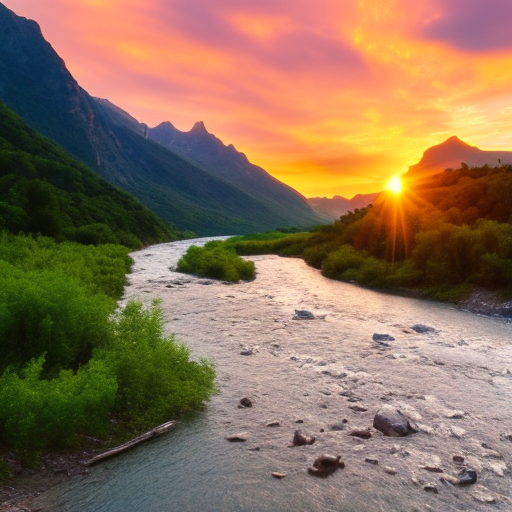

Watermarked image generated!


In [4]:
# Generate watermarked image
prompt = "A beautiful landscape with mountains and a river at sunset"

watermarked_image = tr_watermark.generate_watermarked_media(input_data=prompt)

# Display the watermarked image
watermarked_image.show()
print("Watermarked image generated!")

### 1.3 Detect Watermark in Image

In [5]:
# Detect watermark in the watermarked image
detection_result = tr_watermark.detect_watermark_in_media(watermarked_image)
print("Watermarked image detection result:")
print(detection_result)

100%|██████████| 50/50 [00:01<00:00, 32.23it/s]


Watermarked image detection result:
{'is_watermarked': True, 'l1_distance': 27.09375}


In [5]:
# Generate and test unwatermarked image for comparison
unwatermarked_image = tr_watermark.generate_unwatermarked_media(input_data=prompt)
detection_result_unwatermarked = tr_watermark.detect_watermark_in_media(unwatermarked_image)
print("Unwatermarked image detection result:")
print(detection_result_unwatermarked)

100%|██████████| 50/50 [00:03<00:00, 14.29it/s]

Unwatermarked image detection result:
{'is_watermarked': False, 'l1_distance': 60.6875}


### 1.4 Watermark Visualization

In [7]:
from markdiffusion.visualize.auto_visualization import AutoVisualizer

tr_data_for_visualizer = tr_watermark.get_data_for_visualize(watermarked_image)

tr_visualizer = AutoVisualizer.load('TR', data_for_visualization=tr_data_for_visualizer)

 10%|█         | 5/50 [00:00<00:01, 40.10it/s]

100%|██████████| 50/50 [00:01<00:00, 32.23it/s]


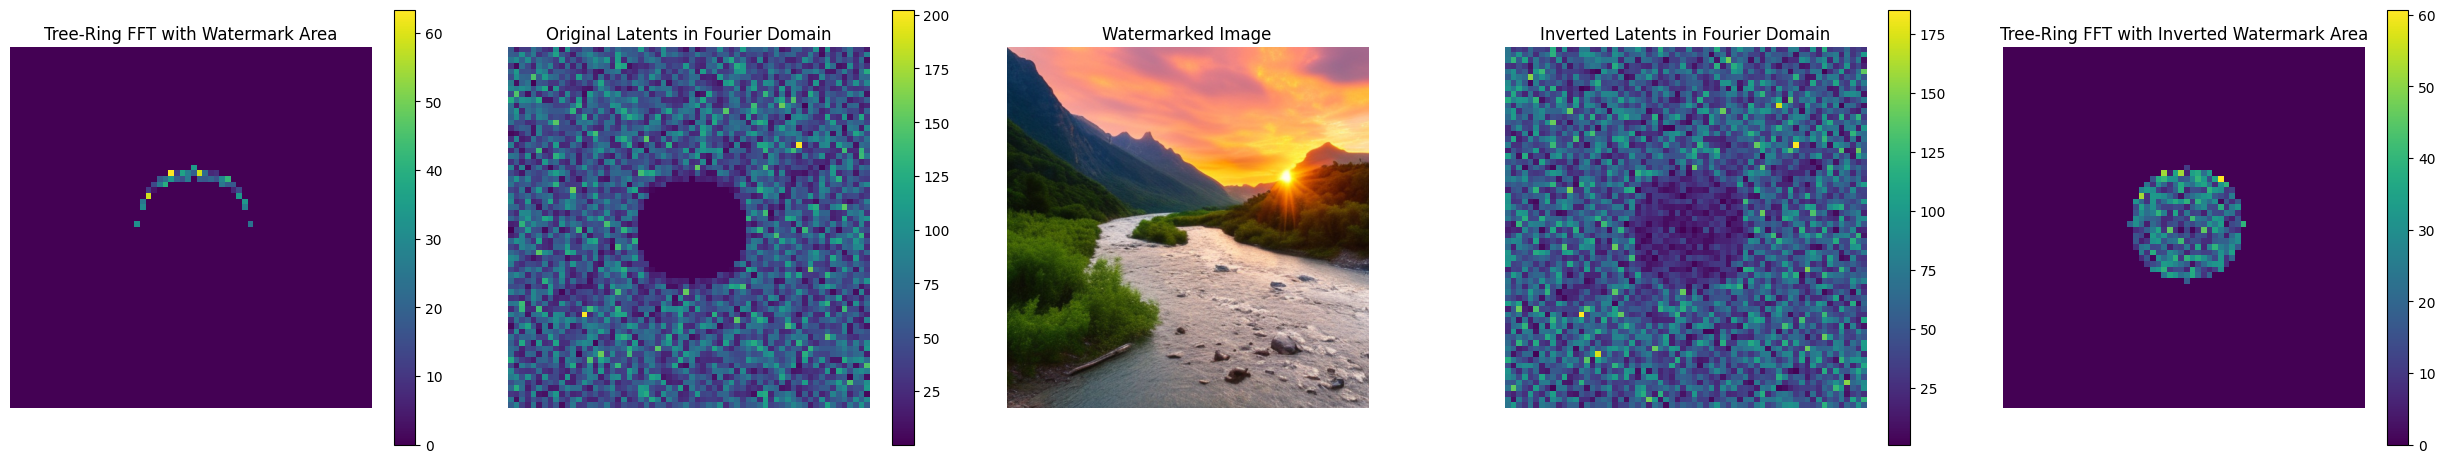

In [8]:
method_kwargs = [{},{"channel": 0}, {}, {"channel": 0}, {}]
fig = tr_visualizer.visualize(
    rows=1,
    cols=5,
    methods=['draw_pattern_fft', 'draw_orig_latents_fft', 'draw_watermarked_image', 'draw_inverted_latents_fft', 'draw_inverted_pattern_fft'],
    method_kwargs=method_kwargs,
    # save_path='TR_watermark_visualization.pdf'
 )

## 2. Video Watermarking with VideoMark

### 2.0 Initialize Video Pipeline

In [ ]:
import os
os.environ["HF_ENDPOINT"] = "https://hf.mirror.com"
from diffusers import TextToVideoSDPipeline, DDIMScheduler

# Video model path
VIDEO_MODEL_PATH = "ali-vilab/text-to-video-ms-1.7b"

# Initialize video scheduler and pipeline
video_scheduler = DDIMScheduler.from_pretrained(VIDEO_MODEL_PATH, subfolder="scheduler")
video_pipe = TextToVideoSDPipeline.from_pretrained(
    VIDEO_MODEL_PATH,
    scheduler=video_scheduler,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

# Create DiffusionConfig for video generation
video_diffusion_config = DiffusionConfig(
    scheduler=video_scheduler,
    pipe=video_pipe,
    device=device,
    image_size=(256, 256),
    guidance_scale=7.5,
    num_inference_steps=25,
    gen_seed=42,
    num_frames=16,
    inversion_type="ddim"
)
print("Video pipeline initialized!")

Loading pipeline components...: 100%|██████████| 5/5 [00:03<00:00,  1.30it/s]
The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Video pipeline initialized!


### 2.1 Load VideoMark Algorithm

In [9]:
# Load VideoMark watermark algorithm
videomark_watermark = AutoWatermark.load('VideoMark', diffusion_config=video_diffusion_config)
print("VideoMark watermark algorithm loaded successfully!")

VideoMark watermark algorithm loaded successfully!


### 2.2 Generate Watermarked Video

100%|██████████| 25/25 [00:38<00:00,  1.53s/it]


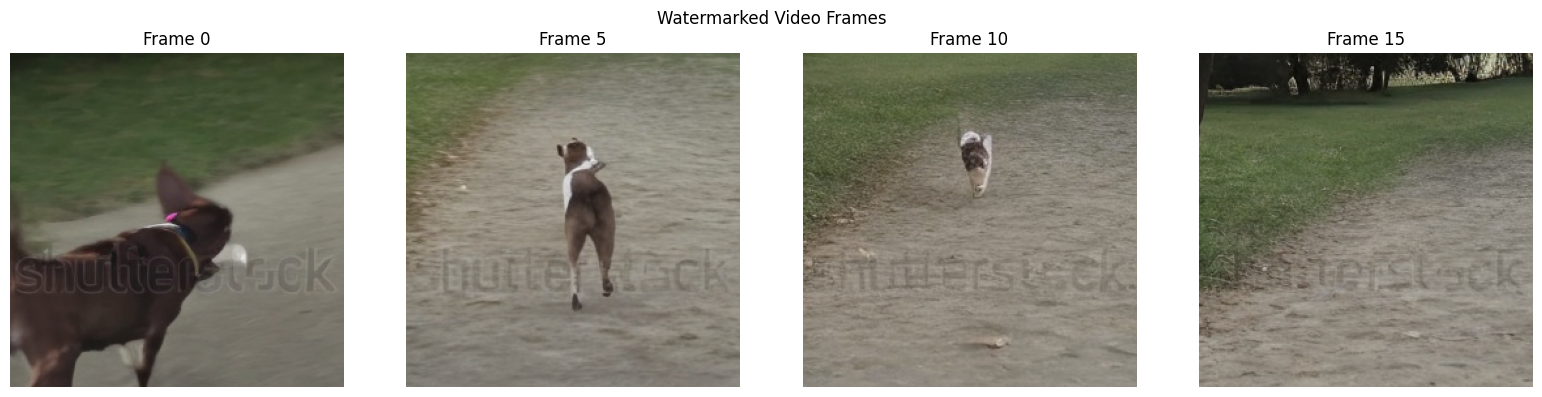

Generated 16 watermarked frames


In [10]:
import matplotlib.pyplot as plt

def display_video_frames(frames, title="Video Frames", num_display=4):
    """Display selected frames from video."""
    indices = [int(i * (len(frames) - 1) / (num_display - 1)) for i in range(num_display)]
    fig, axes = plt.subplots(1, num_display, figsize=(4 * num_display, 4))
    for i, idx in enumerate(indices):
        axes[i].imshow(frames[idx])
        axes[i].set_title(f"Frame {idx}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Generate watermarked video
video_prompt = "A dog running in the park"

watermarked_video = videomark_watermark.generate_watermarked_media(
    input_data=video_prompt,
    num_frames=16
)

# Display frames
display_video_frames(watermarked_video, "Watermarked Video Frames")
print(f"Generated {len(watermarked_video)} watermarked frames")

### 2.3 Detect Watermark in Video

In [ ]:
# Detect watermark in watermarked video
detection_result = videomark_watermark.detect_watermark_in_media(
    watermarked_video,
    detector_type='bit_acc'
)
print("Watermarked video detection result:")
print(f"  is_watermarked: {detection_result['is_watermarked']}")
print(f"  bit_acc: {detection_result['bit_acc']}")

The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
100%|██████████| 25/25 [-1:59:56<00:00, -5.10it/s]
/home/harry/miniconda3/envs/markdiffusion/lib/python3.12/site-packages/ldpc/_legacy_ldpc_v1/_legacy_bp_decoder.py:46: UserWarning: This is the old syntax for the `bp_decoder` from `ldpc v1`. Use the `BpDecoder` class from `ldpc v2` for additional features.
  warnings.warn(
/home/harry/miniconda3/envs/markdiffusion/lib/python3.12/site-packages/ldpc/_legacy_ldpc_v1/_legacy_bp_decoder.py:46: UserWarning: This is the old syntax for the `bp_decoder` from `ldpc v1`. Use the `BpDecoder` class from `ldpc v2` for additional features.
  warnings.warn(


Watermarked video detection result:
  is_watermarked: True
  bit_acc: 1.0


In [ ]:
# Generate and test unwatermarked video for comparison
unwatermarked_video = videomark_watermark.generate_unwatermarked_media(
    input_data=video_prompt,
    num_frames=16
)

detection_result_unwatermarked = videomark_watermark.detect_watermark_in_media(
    unwatermarked_video,
    detector_type='bit_acc'
)
print("Unwatermarked video detection result:")
print(f"  is_watermarked: {detection_result_unwatermarked['is_watermarked']}")
print(f"  bit_acc: {detection_result_unwatermarked['bit_acc']}")

100%|██████████| 25/25 [00:10<00:00,  2.37it/s]
The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
100%|██████████| 25/25 [-1:59:56<00:00, -5.91it/s]


Unwatermarked video detection result:
  is_watermarked: False
  bit_acc: 0.544921875


### 2.4 Video Watermark Visualization

In [19]:
from markdiffusion.visualize.auto_visualization import AutoVisualizer

data_for_visualization = videomark_watermark.get_data_for_visualize(
    video_frames=watermarked_video,
    prompt="",
    guidance_scale=1.0,
    num_inference_steps=25,
)

The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
100%|██████████| 25/25 [00:10<00:00,  2.38it/s]
/home/harry/miniconda3/envs/markdiffusion/lib/python3.12/site-packages/ldpc/_legacy_ldpc_v1/_legacy_bp_decoder.py:46: UserWarning: This is the old syntax for the `bp_decoder` from `ldpc v1`. Use the `BpDecoder` class from `ldpc v2` for additional features.
  warnings.warn(
/home/harry/workspace/markdiffusion_pypi/markdiffusion/watermark/videomark/video_mark.py:527: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prc_codeword=torch.tensor(prc_codeword, dtype=torch.float32),
/home/harry/workspace/markdiffusion_pypi/markdiffusion/watermark/videomark/video_mark.py:528: UserWarning: To copy construct from a tenso

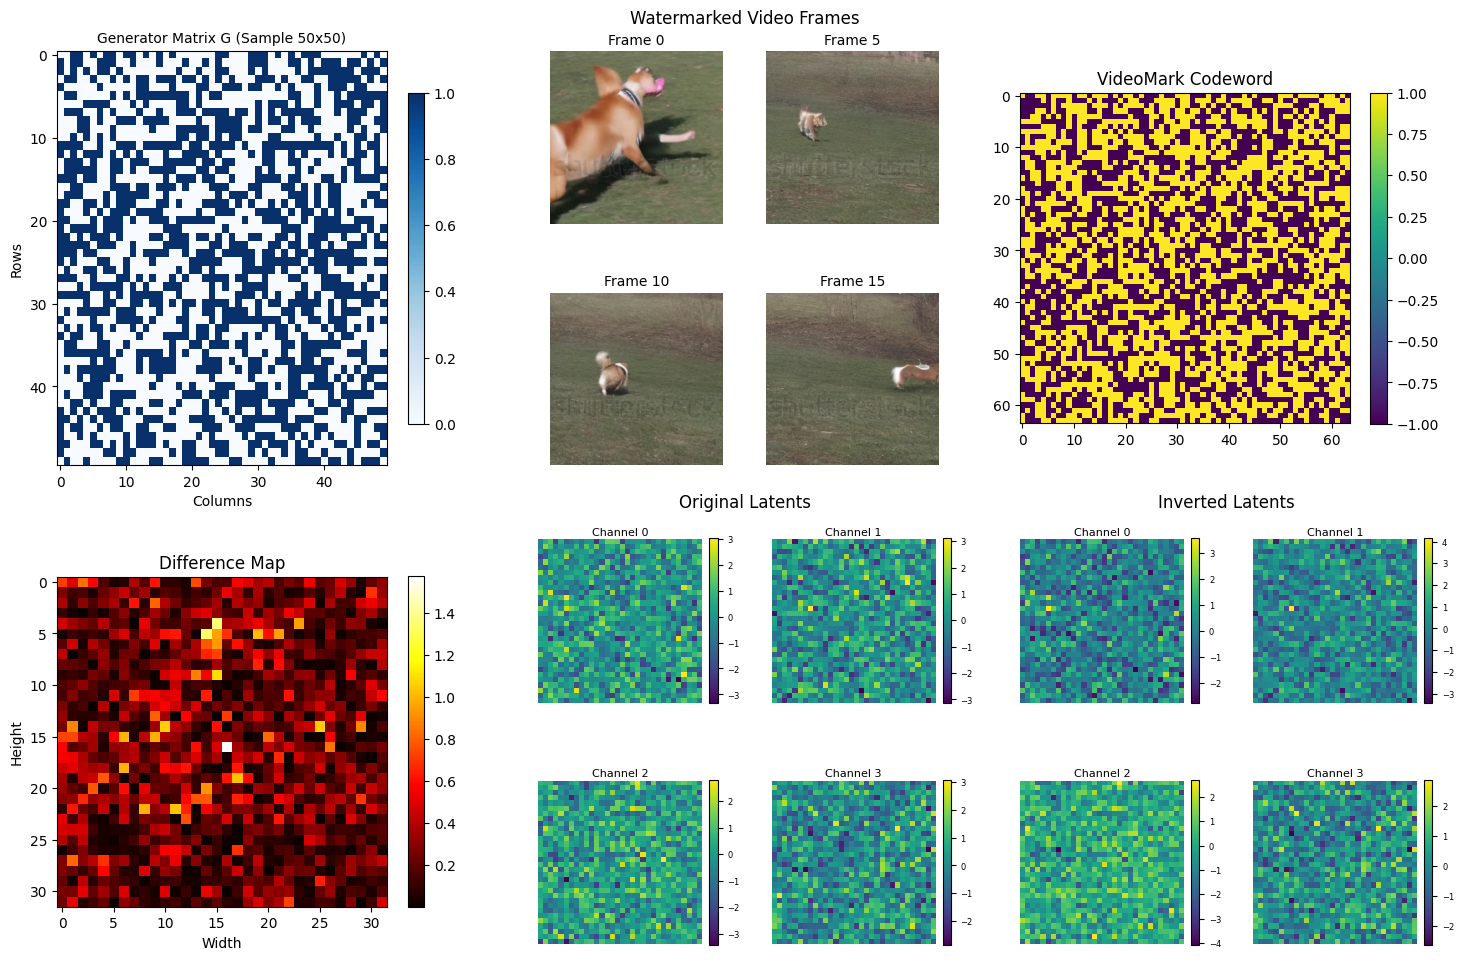

In [ ]:
video_mark_visualizer = AutoVisualizer.load('VideoMark', data_for_visualization=data_for_visualization)

fig = video_mark_visualizer.visualize(
    rows=2, 
    cols=3, 
    methods=['draw_generator_matrix', 'draw_watermarked_video_frames', 'draw_codeword', 'draw_difference_map','draw_orig_latents','draw_inverted_latents'], 
    save_path='VideoMark_watermark_visualization.pdf'
    )

## 3. Test Pipeline

### 3.1 Test Detectability

In [9]:
from markdiffusion.evaluation.dataset import MSCOCODataset
from markdiffusion.evaluation.pipelines.detection import (
    WatermarkedMediaDetectionPipeline, 
    UnWatermarkedMediaDetectionPipeline, 
    DetectionPipelineReturnType
)
from markdiffusion.evaluation.tools.success_rate_calculator import DynamicThresholdSuccessRateCalculator

# Dataset
my_dataset = MSCOCODataset(max_samples=2)
# Watermark
my_watermark = AutoWatermark.load('RI', algorithm_config='config/RI.json', diffusion_config=image_diffusion_config)
# pipeline parameters
labels = ['TPR','TNR','FPR','FNR','F1','P','R','F1','ACC','AUC']
rules = 'best'

# Set up detection pipelines
pipeline1 = WatermarkedMediaDetectionPipeline(
    dataset=my_dataset,
    media_editor_list=[],
    show_progress=True, 
    return_type=DetectionPipelineReturnType.SCORES
)

pipeline2 = UnWatermarkedMediaDetectionPipeline(
    dataset=my_dataset,
    media_editor_list=[],
    show_progress=True, 
    return_type=DetectionPipelineReturnType.SCORES
)

# Configure detection parameters
detection_kwargs = {
    "num_inference_steps": 50,
    "guidance_scale": 1.0,
}

# Calculate success rates
calculator = DynamicThresholdSuccessRateCalculator(
    labels=labels, 
    rule=rules,
    reverse=True
)

results = calculator.calculate(
    pipeline1.evaluate(my_watermark, detection_kwargs=detection_kwargs),
    pipeline2.evaluate(my_watermark, detection_kwargs=detection_kwargs)
)
print(results)

Processing:  50%|█████     | 1/2 [00:03<00:03,  3.16s/it]

{'is_watermarked': True, 'l1_distance': 28.35392926553017}


Processing: 100%|██████████| 2/2 [00:06<00:00,  3.02s/it]


{'is_watermarked': True, 'l1_distance': 25.490839160724892}


Processing:  50%|█████     | 1/2 [00:01<00:01,  1.38s/it]

{'is_watermarked': False, 'l1_distance': 71.2589096055587}


Processing: 100%|██████████| 2/2 [00:02<00:00,  1.38s/it]

{'is_watermarked': False, 'l1_distance': 71.2589096055587}
{'TPR': 1.0, 'TNR': 1.0, 'FPR': 0.0, 'FNR': 0.0, 'F1': 1.0, 'P': 1.0, 'R': 1.0, 'ACC': 1.0, 'AUC': 1.0}


### 3.2 Test Robustness

In [6]:
from markdiffusion.evaluation.dataset import MSCOCODataset
from markdiffusion.evaluation.pipelines.detection import (
    WatermarkedMediaDetectionPipeline, 
    UnWatermarkedMediaDetectionPipeline, 
    DetectionPipelineReturnType
)
from markdiffusion.evaluation.tools.image_editor import JPEGCompression
from markdiffusion.evaluation.tools.success_rate_calculator import DynamicThresholdSuccessRateCalculator

# Dataset
my_dataset = MSCOCODataset(max_samples=2)
# Watermark
my_watermark = AutoWatermark.load('TR', algorithm_config='config/TR.json', diffusion_config=image_diffusion_config)
# pipeline parameters
labels = ['TPR','TNR','FPR','FNR','F1','P','R','F1','ACC','AUC']
rules = 'best'

# Set up detection pipelines
pipeline1 = WatermarkedMediaDetectionPipeline(
    dataset=my_dataset,
    media_editor_list=[JPEGCompression(quality=60)],
    show_progress=True, 
    return_type=DetectionPipelineReturnType.SCORES
)

pipeline2 = UnWatermarkedMediaDetectionPipeline(
    dataset=my_dataset,
    media_editor_list=[],
    show_progress=True, 
    return_type=DetectionPipelineReturnType.SCORES
)

# Configure detection parameters
detection_kwargs = {
    "num_inference_steps": 50,
    "guidance_scale": 1.0,
}

# Calculate success rates
calculator = DynamicThresholdSuccessRateCalculator(
    labels=labels, 
    rule=rules,
    reverse=True
)

results = calculator.calculate(
    pipeline1.evaluate(my_watermark, detection_kwargs=detection_kwargs),
    pipeline2.evaluate(my_watermark, detection_kwargs=detection_kwargs)
)
print(results)

Processing:  50%|█████     | 1/2 [00:06<00:06,  6.22s/it]

{'is_watermarked': True, 'l1_distance': 36.875}


Processing: 100%|██████████| 2/2 [00:12<00:00,  6.04s/it]


{'is_watermarked': True, 'l1_distance': 31.703125}


Processing:  50%|█████     | 1/2 [00:02<00:02,  2.24s/it]

{'is_watermarked': False, 'l1_distance': 56.71875}


Processing: 100%|██████████| 2/2 [00:04<00:00,  2.26s/it]

{'is_watermarked': False, 'l1_distance': 56.71875}
{'TPR': 1.0, 'TNR': 1.0, 'FPR': 0.0, 'FNR': 0.0, 'F1': 1.0, 'P': 1.0, 'R': 1.0, 'ACC': 1.0, 'AUC': 1.0}


## 4. Test Quality

In [7]:
from markdiffusion.evaluation.pipelines.image_quality_analysis import DirectImageQualityAnalysisPipeline
from markdiffusion.evaluation.dataset import StableDiffusionPromptsDataset
from markdiffusion.watermark.auto_watermark import AutoWatermark
from markdiffusion.evaluation.tools.image_quality_analyzer import PSNRAnalyzer, SSIMAnalyzer

# Dataset
dataset = StableDiffusionPromptsDataset(max_samples=2, split="train")

# Watermark
robin_watermark = AutoWatermark.load('TR', algorithm_config='config/TR.json', diffusion_config=image_diffusion_config)

# 3. initialize Pipeline
iq_pipe = DirectImageQualityAnalysisPipeline(
    dataset=dataset,
    analyzers=[PSNRAnalyzer(), SSIMAnalyzer()], 
    unwatermarked_image_source='generated', 
    store_path='results/robin_iq'
)

print("Running Image Quality Analysis for TR...")
iq_results = iq_pipe.evaluate(
    watermark=robin_watermark,
    generation_kwargs={'num_inference_steps': 30}
)

print("\n=== Image Quality Results ===")
print(iq_results)

Generating train split: 73718 examples [00:00, 1204178.47 examples/s]
Generating test split: 8192 examples [00:00, 930376.60 examples/s]


Running Image Quality Analysis for TR...
results/robin_iq


Generating images for quality analysis:   0%|          | 0/2 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (101 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['incev , in style of lee souder , in plastic , dark atmosphere , tilt shift , depth of field ,']
100%|██████████| 30/30 [00:02<00:00, 13.33it/s]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['incev , in style of lee souder , in plastic , dark atmosphere , tilt shift , depth of field ,']
100%|██████████| 30/30 [00:01<00:00, 15.25it/s]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['trending on art station']
Analyzing quality for SSIMAnalyzer: 100%|██████████| 2/2 [00:00<00:00, 123.67it/s]


=== Image Quality Results ===
{'watermarked': {'PSNRAnalyzer': np.float64(11.307589054107666), 'SSIMAnalyzer': np.float64(0.628803938627243)}, 'unwatermarked': {'PSNRAnalyzer': np.float64(11.307589054107666), 'SSIMAnalyzer': np.float64(0.628803938627243)}}


In [8]:
from markdiffusion.evaluation.pipelines.video_quality_analysis import DirectVideoQualityAnalysisPipeline
from markdiffusion.evaluation.dataset import VBenchDataset
from markdiffusion.watermark.auto_watermark import AutoWatermark
from markdiffusion.evaluation.tools.video_quality_analyzer import SubjectConsistencyAnalyzer

video_dataset = VBenchDataset(max_samples=2, dimension="object_class")
print(f"Loaded video prompt: {video_dataset.get_prompt(0)}")

vs_watermark = AutoWatermark.load('VideoMark', algorithm_config='config/VideoMark.json', diffusion_config=video_diffusion_config)

vq_pipe = DirectVideoQualityAnalysisPipeline(
    dataset=video_dataset,
    analyzers=[SubjectConsistencyAnalyzer()], 
    store_path='results/videoshield_vq'
)

print("Running Video Quality Analysis for VideoMark...")
vq_results = vq_pipe.evaluate(
    watermark=vs_watermark,
    generation_kwargs={'num_frames': 16, 'height': 256, 'width': 256}
)

print("\n=== Video Quality Results ===")
print(vq_results)

Loaded video prompt: a person
Download complete: dino_vitb16_full.pth
Running Video Quality Analysis for VideoMark...


Generating videos for quality analysis: 100%|██████████| 2/2 [00:44<00:00, 22.15s/it]
Analyzing quality for SubjectConsistencyAnalyzer:   0%|          | 0/2 [00:00<?, ?it/s]/home/harry/miniconda3/envs/markdiffusion/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
Analyzing quality for SubjectConsistencyAnalyzer: 100%|██████████| 2/2 [00:01<00:00,  1.44it/s]


=== Video Quality Results ===
{'watermarked': {'SubjectConsistencyAnalyzer': np.float64(0.8929649025201798)}, 'unwatermarked': {'SubjectConsistencyAnalyzer': np.float64(0.9511837104956309)}}
